# Stars and Bars

In the previous notebooks we learned:
- **Counting** — product rule, sum rule
- **Permutations** — ordered arrangements
- **Combinations** — unordered selections (without repetition)

But what if we are allowed to **repeat** choices, or need to **distribute identical objects** into groups?

Stars and bars is a powerful visual technique that answers two core questions:

1. **Combinations with repetition** — How many ways to choose $r$ items from $n$ types when repetition is allowed?
2. **Bucketing** — How many ways to distribute $n$ identical objects into $k$ distinct buckets?

We will:
1. Introduce the stars and bars representation
2. Derive the formula for distributing identical objects into distinct buckets
3. Show that combinations with repetition is the same problem
4. Handle variants with constraints (e.g. minimum per bucket)
5. Work through examples and practice problems

In [33]:
import math
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def C(n, r):
    """Combinations: C(n, r) = n! / (r! * (n - r)!)"""
    if r < 0 or r > n:
        return 0
    return math.factorial(n) // (math.factorial(r) * math.factorial(n - r))

print("Libraries imported successfully!")


Libraries imported successfully!


---
## 1. The Stars and Bars Idea

Imagine you have **5 identical cookies** and want to distribute them among **3 children**.

Since the cookies are identical, the only thing that matters is **how many** each child gets — not *which* cookies they get.

### The Representation

Represent each cookie as a **star** (★) and separate children's groups using **bars** (|).

With **3 children** we need **2 bars** to create **3 compartments**. Count the stars in each compartment to read off the distribution.

| Stars and Bars | Child 1 | Child 2 | Child 3 | Comment |
|---|:---:|:---:|:---:|---|
| `★ ★ ★ ★ ★ ǀ ǀ` | 5 | 0 | 0 | Child 1 gets all |
| `ǀ ★ ★ ★ ★ ★ ǀ` | 0 | 5 | 0 | Child 2 gets all |
| `ǀ ǀ ★ ★ ★ ★ ★` | 0 | 0 | 5 | Child 3 gets all |
| `★ ★ ǀ ★ ★ ★ ǀ` | 2 | 3 | 0 | Two children share, one empty |
| `★ ★ ★ ǀ ǀ ★ ★` | 3 | 0 | 2 | Two children share, one empty |
| `ǀ ★ ★ ǀ ★ ★ ★` | 0 | 2 | 3 | Two children share, one empty |
| `★ ǀ ★ ǀ ★ ★ ★` | 1 | 1 | 3 | All children get something |
| `★ ★ ǀ ★ ★ ǀ ★` | 2 | 2 | 1 | All children get something |
| `★ ǀ ★ ★ ǀ ★ ★` | 1 | 2 | 2 | All children get something |
| `★ ★ ǀ ★ ǀ ★ ★` | 2 | 1 | 2 | All children get something |

**Notice**:
- When both bars are on the **same side** (e.g. `★ ★ ★ ★ ★ | |`), one child gets everything and the others get 0
- When bars are **adjacent** (`| |`), the compartment between them is empty — that child gets 0
- When bars are **spread out** (e.g. `★ | ★ ★ | ★ ★`), every child gets at least 1

### Key Observations

- **Stars** = objects being distributed (identical)
- **Bars** = dividers between buckets (distinct groups)
- $k$ buckets need exactly $k - 1$ bars
- An empty compartment (two bars next to each other, like `| |`) means that bucket gets **0** objects
- The stars **between** two consecutive bars belong to that bucket
- Every arrangement of stars and bars gives **exactly one** distribution, and vice versa — this is a **one-to-one correspondence**

In [34]:
# Visualize all distributions of 5 cookies among 3 children
n = 5  # cookies (stars)
k = 3  # children (buckets)

print(f"Distributing {n} identical cookies among {k} children")
print(f"Stars: {n}, Bars: {k - 1}")
print()

count = 0
for c1 in range(n + 1):
    for c2 in range(n - c1 + 1):
        c3 = n - c1 - c2
        stars_bars = "★ " * c1
        stars_bars += "| "
        stars_bars += "★ " * c2
        stars_bars += "| "
        stars_bars += "★ " * c3
        stars_bars = stars_bars.strip()
        count += 1
        print(f"  {count:>2}. ({c1}, {c2}, {c3})  →  {stars_bars}")

print()
print(f"Total distributions: {count}")

Distributing 5 identical cookies among 3 children
Stars: 5, Bars: 2

   1. (0, 0, 5)  →  | | ★ ★ ★ ★ ★
   2. (0, 1, 4)  →  | ★ | ★ ★ ★ ★
   3. (0, 2, 3)  →  | ★ ★ | ★ ★ ★
   4. (0, 3, 2)  →  | ★ ★ ★ | ★ ★
   5. (0, 4, 1)  →  | ★ ★ ★ ★ | ★
   6. (0, 5, 0)  →  | ★ ★ ★ ★ ★ |
   7. (1, 0, 4)  →  ★ | | ★ ★ ★ ★
   8. (1, 1, 3)  →  ★ | ★ | ★ ★ ★
   9. (1, 2, 2)  →  ★ | ★ ★ | ★ ★
  10. (1, 3, 1)  →  ★ | ★ ★ ★ | ★
  11. (1, 4, 0)  →  ★ | ★ ★ ★ ★ |
  12. (2, 0, 3)  →  ★ ★ | | ★ ★ ★
  13. (2, 1, 2)  →  ★ ★ | ★ | ★ ★
  14. (2, 2, 1)  →  ★ ★ | ★ ★ | ★
  15. (2, 3, 0)  →  ★ ★ | ★ ★ ★ |
  16. (3, 0, 2)  →  ★ ★ ★ | | ★ ★
  17. (3, 1, 1)  →  ★ ★ ★ | ★ | ★
  18. (3, 2, 0)  →  ★ ★ ★ | ★ ★ |
  19. (4, 0, 1)  →  ★ ★ ★ ★ | | ★
  20. (4, 1, 0)  →  ★ ★ ★ ★ | ★ |
  21. (5, 0, 0)  →  ★ ★ ★ ★ ★ | |

Total distributions: 21


---
## 2. Bucketing — Distributing Identical Objects into Distinct Buckets

### The Problem

How many ways can we place $n$ **identical** objects into $k$ **distinct** buckets?

(Each bucket can hold 0 or more objects.)

### Step-by-Step Derivation

**Step 1: Translate to stars and bars**

Represent the distribution as a sequence of symbols:
- $n$ **stars** (one per object)
- $k - 1$ **bars** (one fewer than the number of buckets)

Total symbols in the sequence: $n + (k - 1) = n + k - 1$

**Step 2: Count the arrangements**

Every arrangement of these $n + k - 1$ symbols gives a valid distribution, and every distribution gives a unique arrangement.

So the question becomes: in a row of $n + k - 1$ **positions**, **which positions are bars?**

We need to **choose** $k - 1$ positions (out of $n + k - 1$) for the bars — the remaining positions automatically become stars. This is a **combination**:

$$\binom{n + k - 1}{k - 1}$$

Equivalently, we could choose which $n$ positions are stars:

$$\binom{n + k - 1}{n}$$

Both give the same answer by the symmetry property $C(m, r) = C(m, m-r)$.

### Concrete Example

For $n = 5$ cookies, $k = 3$ children:

- Total symbols: $5$ stars + $2$ bars = $7$ positions
- We must choose which **2** of 7 positions become bars → $\binom{7}{2} = 21$
- Or which **5** of 7 positions become stars → $\binom{7}{5} = 21$ ✓

Here are a few bar placements and the distributions they produce (**A** = Child 1, **B** = Child 2, **C** = Child 3):

<table>
<tr>
  <th>Bars at</th>
  <th>Sequence &amp; bucket assignment</th>
  <th>Result</th>
  <th>Comment</th>
</tr>
<tr>
  <td>6, 7</td>
  <td><pre style="margin:0">*  *  *  *  *  |  |
A  A  A  A  A  .  .</pre></td>
  <td><b>(5, 0, 0)</b></td>
  <td>Child 1 gets all — bars pushed to end</td>
</tr>
<tr>
  <td>1, 7</td>
  <td><pre style="margin:0">|  *  *  *  *  *  |
.  B  B  B  B  B  .</pre></td>
  <td><b>(0, 5, 0)</b></td>
  <td>Child 2 gets all — bars at edges</td>
</tr>
<tr>
  <td>1, 2</td>
  <td><pre style="margin:0">|  |  *  *  *  *  *
.  .  C  C  C  C  C</pre></td>
  <td><b>(0, 0, 5)</b></td>
  <td>Child 3 gets all — bars pushed to start</td>
</tr>
<tr>
  <td>3, 7</td>
  <td><pre style="margin:0">*  *  |  *  *  *  |
A  A  .  B  B  B  .</pre></td>
  <td><b>(2, 3, 0)</b></td>
  <td>Two children share, Child 3 empty</td>
</tr>
<tr>
  <td>3, 4</td>
  <td><pre style="margin:0">*  *  |  |  *  *  *
A  A  .  .  C  C  C</pre></td>
  <td><b>(2, 0, 3)</b></td>
  <td>Adjacent bars → Child 2 gets 0</td>
</tr>
<tr>
  <td>2, 5</td>
  <td><pre style="margin:0">*  |  *  *  |  *  *
A  .  B  B  .  C  C</pre></td>
  <td><b>(1, 2, 2)</b></td>
  <td>All get something — bars spread out</td>
</tr>
<tr>
  <td>3, 5</td>
  <td><pre style="margin:0">*  *  |  *  |  *  *
A  A  .  B  .  C  C</pre></td>
  <td><b>(2, 1, 2)</b></td>
  <td>All get something</td>
</tr>
<tr>
  <td>4, 6</td>
  <td><pre style="margin:0">*  *  *  |  *  |  *
A  A  A  .  B  .  C</pre></td>
  <td><b>(3, 1, 1)</b></td>
  <td>All get something</td>
</tr>
</table>

<br><br>

> **Key insight**: Each unique pair of bar positions gives a different distribution. 7 positions, choose 2 for bars → $\binom{7}{2} = 21$ distributions total.

### Formula: Bucketing

$$\text{Ways to place } n \text{ identical objects into } k \text{ distinct buckets} = \binom{n + k - 1}{k - 1} = \binom{n + k - 1}{n}$$

In [35]:
# Verify the formula against our brute-force count
n = 5  # objects (stars)
k = 3  # buckets

formula_result = C(n + k - 1, k - 1)

print(f"Objects: {n}, Buckets: {k}")
print(f"Stars: {n}, Bars: {k - 1}, Total symbols: {n + k - 1}")
print()
print(f"C({n + k - 1}, {k - 1}) = C({n + k - 1}, {n}) = {formula_result}")
print()

# Also verify using the other form
alt_result = C(n + k - 1, n)
print(f"Symmetry check: C({n + k - 1}, {k - 1}) = {formula_result}, C({n + k - 1}, {n}) = {alt_result}")
print(f"Match: {'✓' if formula_result == alt_result else '✗'}")

Objects: 5, Buckets: 3
Stars: 5, Bars: 2, Total symbols: 7

C(7, 2) = C(7, 5) = 21

Symmetry check: C(7, 2) = 21, C(7, 5) = 21
Match: ✓


In [36]:
# Verify formula for several (n, k) pairs by brute force
def count_distributions_brute_force(n, k):
    """Count ways to distribute n identical objects into k buckets (brute force)."""
    if k == 1:
        return 1
    count = 0
    for combo in combinations_with_replacement(range(n + 1), k):
        if sum(combo) == n:
            # Count all permutations of this partition
            # Use set of permutations to avoid duplicates
            from itertools import permutations as perms
            unique = set(perms(combo))
            count += len(unique)
    return count

print("n    k    formula C(n+k-1, k-1)    brute force    Match?")
print("-" * 56)
for n, k in [(3, 2), (4, 3), (5, 3), (6, 4), (2, 5), (0, 3), (3, 1)]:
    formula = C(n + k - 1, k - 1)
    brute = count_distributions_brute_force(n, k)
    match = "✓" if formula == brute else "✗"
    print(f"{n:<5}{k:<5}{formula:<22}{brute:<15}{match}")

n    k    formula C(n+k-1, k-1)    brute force    Match?
--------------------------------------------------------
3    2    4                     4              ✓
4    3    15                    15             ✓
5    3    21                    21             ✓
6    4    84                    84             ✓
2    5    15                    15             ✓
0    3    1                     1              ✓
3    1    1                     1              ✓


### Example 1: Distributing Candies

You have **10 identical candies** and **4 children**. How many ways to distribute all the candies? (A child may get 0.)

$$\binom{10 + 4 - 1}{4 - 1} = \binom{13}{3} = 286$$

In [37]:
n = 10  # candies
k = 4   # children

result = C(n + k - 1, k - 1)

print(f"Candies: {n}, Children: {k}")
print(f"C({n} + {k} - 1, {k} - 1) = C({n + k - 1}, {k - 1}) = {result}")

Candies: 10, Children: 4
C(10 + 4 - 1, 4 - 1) = C(13, 3) = 286


### Example 2: Solutions to an Equation

How many **non-negative integer solutions** does the equation $x_1 + x_2 + x_3 + x_4 = 12$ have?

This is the same as distributing 12 identical objects into 4 buckets.

$$\binom{12 + 4 - 1}{4 - 1} = \binom{15}{3} = 455$$

In [38]:
n = 12  # total
k = 4   # variables (buckets)

result = C(n + k - 1, k - 1)

print(f"Equation: x₁ + x₂ + x₃ + x₄ = {n}")
print(f"Non-negative integer solutions: C({n + k - 1}, {k - 1}) = {result}")
print()

# Verify with brute force for a smaller case
small_n = 5
small_k = 3
count = 0
solutions = []
for x1 in range(small_n + 1):
    for x2 in range(small_n - x1 + 1):
        x3 = small_n - x1 - x2
        count += 1
        solutions.append((x1, x2, x3))

formula = C(small_n + small_k - 1, small_k - 1)
print(f"Verification: x₁ + x₂ + x₃ = {small_n}")
print(f"Brute force: {count} solutions")
print(f"Formula: C({small_n + small_k - 1}, {small_k - 1}) = {formula}")
print(f"Match: {'✓' if count == formula else '✗'}")

Equation: x₁ + x₂ + x₃ + x₄ = 12
Non-negative integer solutions: C(15, 3) = 455

Verification: x₁ + x₂ + x₃ = 5
Brute force: 21 solutions
Formula: C(7, 2) = 21
Match: ✓


### Example 3: Putting Identical Balls into Labeled Boxes

Place **7 identical balls** into **5 labeled boxes**.

$$\binom{7 + 5 - 1}{5 - 1} = \binom{11}{4} = 330$$

In [39]:
n = 7  # balls
k = 5  # boxes

result = C(n + k - 1, k - 1)

print(f"Identical balls: {n}, Labeled boxes: {k}")
print(f"C({n + k - 1}, {k - 1}) = {result}")

Identical balls: 7, Labeled boxes: 5
C(11, 4) = 330


## 3. Combinations with Repetition (Multisets)

### The Problem

An ice cream shop has **4 flavors**: Vanilla, Chocolate, Strawberry, Mango. You choose **3 scoops**, and you **can repeat** flavors.

How many different orders are possible?

Order doesn't matter — (Vanilla, Chocolate, Chocolate) is the same as (Chocolate, Vanilla, Chocolate).

### Why This Is the Same as Bucketing

The key insight is to **reframe** the problem: instead of thinking about picking scoops, think about **distributing scoops into flavor buckets**.

- The **flavors** are the **buckets** ($k = 4$)
- The **scoops** are the **identical objects** ($n = 3$) — each scoop is "identical" in the sense that we only care about *which flavor* it is, not *which scoop* it is
- Choosing 3 scoops with repetition = distributing 3 scoops among 4 flavors

For $n = 3$ scoops, $k = 4$ flavors: $3$ stars + $3$ bars = $6$ positions. Choose $3$ for bars.

Labels: **V** = Vanilla, **C** = Chocolate, **S** = Strawberry, **M** = Mango

<table>
<tr>
  <th>Bars at</th>
  <th>Sequence &amp; flavor assignment</th>
  <th>Result (V, C, S, M)</th>
  <th>Comment</th>
</tr>
<tr>
  <td>4, 5, 6</td>
  <td><pre style="margin:0">*  *  *  |  |  |
V  V  V  .  .  .</pre></td>
  <td><b>(3, 0, 0, 0)</b></td>
  <td>All Vanilla — bars pushed to end</td>
</tr>
<tr>
  <td>1, 5, 6</td>
  <td><pre style="margin:0">|  *  *  *  |  |
.  C  C  C  .  .</pre></td>
  <td><b>(0, 3, 0, 0)</b></td>
  <td>All Chocolate — first bar at start</td>
</tr>
<tr>
  <td>1, 2, 6</td>
  <td><pre style="margin:0">|  |  *  *  *  |
.  .  S  S  S  .</pre></td>
  <td><b>(0, 0, 3, 0)</b></td>
  <td>All Strawberry — bars at edges</td>
</tr>
<tr>
  <td>1, 2, 3</td>
  <td><pre style="margin:0">|  |  |  *  *  *
.  .  .  M  M  M</pre></td>
  <td><b>(0, 0, 0, 3)</b></td>
  <td>All Mango — bars pushed to start</td>
</tr>
<tr>
  <td>2, 4, 6</td>
  <td><pre style="margin:0">*  |  *  |  *  |
V  .  C  .  S  .</pre></td>
  <td><b>(1, 1, 1, 0)</b></td>
  <td>Even spread, Mango empty</td>
</tr>
<tr>
  <td>2, 5, 6</td>
  <td><pre style="margin:0">*  |  *  *  |  |
V  .  C  C  .  .</pre></td>
  <td><b>(1, 2, 0, 0)</b></td>
  <td>Vanilla + Chocolate only</td>
</tr>
<tr>
  <td>3, 4, 6</td>
  <td><pre style="margin:0">*  *  |  |  *  |
V  V  .  .  S  .</pre></td>
  <td><b>(2, 0, 1, 0)</b></td>
  <td>Adjacent bars → Chocolate gets 0</td>
</tr>
<tr>
  <td>2, 4, 5</td>
  <td><pre style="margin:0">*  |  *  |  |  *
V  .  C  .  .  M</pre></td>
  <td><b>(1, 1, 0, 1)</b></td>
  <td>Strawberry empty — adjacent bars</td>
</tr>
</table>

<br><br>

> **Key insight**: 6 positions, choose 3 for bars → $\binom{6}{3} = 20$ distributions total.

### How to Think About It

1. **Line up the scoops** as stars: `★ ★ ★` (3 scoops)
2. **Insert 3 bars** to create 4 flavor compartments
3. The number of stars in each compartment = how many scoops of that flavor
4. Total symbols: $3 + 3 = 6$ → choose 3 positions for stars: $\binom{6}{3} = 20$

### Formula: Combinations with Repetition

Choosing $r$ items from $n$ types, repetition allowed, order doesn't matter:

$$\binom{n + r - 1}{r} = \binom{n + r - 1}{n - 1}$$

This is the **same formula** as bucketing with $n$ objects into $k = n$ buckets — just different variable names:

| Bucketing | Combinations with repetition |
|-----------|-----------------------------|
| $n$ objects | $r$ items to choose |
| $k$ buckets | $n$ types to choose from |
| $\binom{n+k-1}{k-1}$ | $\binom{n+r-1}{n-1}$ |

> **Tip**: Whenever you see "choose with repetition, order doesn't matter," think: *which flavor bucket does each scoop go into?* That's stars and bars.

In [40]:
# Ice cream example
flavors = ["Vanilla", "Chocolate", "Strawberry", "Mango"]
n_types = len(flavors)
r_choose = 3

formula_result = C(n_types + r_choose - 1, r_choose)

print(f"Flavors: {flavors} ({n_types} types)")
print(f"Scoops to choose: {r_choose}")
print(f"C({n_types} + {r_choose} - 1, {r_choose}) = C({n_types + r_choose - 1}, {r_choose}) = {formula_result}")
print()

# List all possibilities
all_choices = list(combinations_with_replacement(flavors, r_choose))
for i, choice in enumerate(all_choices, 1):
    print(f"  {i:>2}. {', '.join(choice)}")

print()
print(f"Total: {len(all_choices)}")
print(f"Match with formula: {'✓' if len(all_choices) == formula_result else '✗'}")

Flavors: ['Vanilla', 'Chocolate', 'Strawberry', 'Mango'] (4 types)
Scoops to choose: 3
C(4 + 3 - 1, 3) = C(6, 3) = 20

   1. Vanilla, Vanilla, Vanilla
   2. Vanilla, Vanilla, Chocolate
   3. Vanilla, Vanilla, Strawberry
   4. Vanilla, Vanilla, Mango
   5. Vanilla, Chocolate, Chocolate
   6. Vanilla, Chocolate, Strawberry
   7. Vanilla, Chocolate, Mango
   8. Vanilla, Strawberry, Strawberry
   9. Vanilla, Strawberry, Mango
  10. Vanilla, Mango, Mango
  11. Chocolate, Chocolate, Chocolate
  12. Chocolate, Chocolate, Strawberry
  13. Chocolate, Chocolate, Mango
  14. Chocolate, Strawberry, Strawberry
  15. Chocolate, Strawberry, Mango
  16. Chocolate, Mango, Mango
  17. Strawberry, Strawberry, Strawberry
  18. Strawberry, Strawberry, Mango
  19. Strawberry, Mango, Mango
  20. Mango, Mango, Mango

Total: 20
Match with formula: ✓


#### Stars and Bars Visual for 3 Scoops, 4 Flavors

Each row below shows the stars-and-bars encoding: stars (★) go into buckets separated by bars (|), where the buckets represent **Vanilla | Chocolate | Strawberry | Mango**.

Reading guide — for any row, count the stars in each compartment:
```
★ ★ | ★ | |     → 2 stars before 1st bar (Vanilla=2), 1 star between bars 1&2 (Chocolate=1),
                   0 between bars 2&3 (Strawberry=0), 0 after 3rd bar (Mango=0)
```

In [41]:
# Stars and bars visual: 3 scoops (★) among 4 flavors (| | |)
flavors = ["Vanilla", "Chocolate", "Strawberry", "Mango"]
scoops = 3
k = len(flavors)

print(f"Distributing {scoops} scoops among {k} flavors: {', '.join(flavors)}")
print(f"Stars: {scoops}, Bars: {k - 1}")
print()
print(f"{'#':>3}   {'Distribution':<28} {'Stars and Bars':<24} {'Scoops'}")
print("-" * 85)

count = 0
for v in range(scoops + 1):
    for c in range(scoops - v + 1):
        for s in range(scoops - v - c + 1):
            m = scoops - v - c - s
            count += 1
            dist = f"V={v}, C={c}, S={s}, M={m}"
            sb = "★ " * v + "| " + "★ " * c + "| " + "★ " * s + "| " + "★ " * m
            sb = sb.strip()

            parts = []
            if v > 0:
                parts.append(f"{v} Vanilla")
            if c > 0:
                parts.append(f"{c} Chocolate")
            if s > 0:
                parts.append(f"{s} Strawberry")
            if m > 0:
                parts.append(f"{m} Mango")
            scoops_desc = ", ".join(parts) if parts else "(none of each)"

            print(f"{count:>3}.  {dist:<28} {sb:<24} {scoops_desc}")

print()
print(f"Total: {count}  =  C({scoops} + {k} - 1, {scoops}) = C({scoops + k - 1}, {scoops}) = {C(scoops + k - 1, scoops)}")

Distributing 3 scoops among 4 flavors: Vanilla, Chocolate, Strawberry, Mango
Stars: 3, Bars: 3

  #   Distribution                 Stars and Bars           Scoops
-------------------------------------------------------------------------------------
  1.  V=0, C=0, S=0, M=3           | | | ★ ★ ★              3 Mango
  2.  V=0, C=0, S=1, M=2           | | ★ | ★ ★              1 Strawberry, 2 Mango
  3.  V=0, C=0, S=2, M=1           | | ★ ★ | ★              2 Strawberry, 1 Mango
  4.  V=0, C=0, S=3, M=0           | | ★ ★ ★ |              3 Strawberry
  5.  V=0, C=1, S=0, M=2           | ★ | | ★ ★              1 Chocolate, 2 Mango
  6.  V=0, C=1, S=1, M=1           | ★ | ★ | ★              1 Chocolate, 1 Strawberry, 1 Mango
  7.  V=0, C=1, S=2, M=0           | ★ | ★ ★ |              1 Chocolate, 2 Strawberry
  8.  V=0, C=2, S=0, M=1           | ★ ★ | | ★              2 Chocolate, 1 Mango
  9.  V=0, C=2, S=1, M=0           | ★ ★ | ★ |              2 Chocolate, 1 Strawberry
 10.  V=0, C=3, S

#### More Cases: Varying the Number of Scoops

How does the number of possible orders change as we pick more scoops from the same 4 flavors (Vanilla, Chocolate, Strawberry, Mango)?

We always have **3 bars** (for 4 flavors) but the number of **stars** changes:

| Scoops ($r$) | Stars + Bars | Choose bars | Formula | Result |
|:---:|:---:|:---:|---|:---:|
| 1 | 1 + 3 = 4 symbols | $\binom{4}{3}$ or $\binom{4}{1}$ | $C(4, 1)$ | **4** |
| 2 | 2 + 3 = 5 symbols | $\binom{5}{3}$ or $\binom{5}{2}$ | $C(5, 2)$ | **10** |
| 3 | 3 + 3 = 6 symbols | $\binom{6}{3}$ or $\binom{6}{3}$ | $C(6, 3)$ | **20** |
| 4 | 4 + 3 = 7 symbols | $\binom{7}{3}$ or $\binom{7}{4}$ | $C(7, 4)$ | **35** |
| 5 | 5 + 3 = 8 symbols | $\binom{8}{3}$ or $\binom{8}{5}$ | $C(8, 5)$ | **56** |
| 6 | 6 + 3 = 9 symbols | $\binom{9}{3}$ or $\binom{9}{6}$ | $C(9, 6)$ | **84** |

Notice: adding one more scoop doesn't just add a few options — the count grows quickly because each new star can go into **any** of the 4 flavor buckets.

In [42]:
# More cases: 4 flavors, varying scoops from 1 to 6
flavors = ["Vanilla", "Chocolate", "Strawberry", "Mango"]
k = len(flavors)

print(f"Flavors: {', '.join(flavors)} ({k} types)")
print()
print(f"{'Scoops':>6}   {'Formula':>20}   {'Result':>6}   {'Sample stars and bars'}")
print("-" * 75)

for r in range(1, 7):
    result = C(k + r - 1, r)
    # Build one sample: all scoops go to the first flavor
    sample = "★ " * r + "| " * (k - 1)
    sample = sample.strip()
    print(f"{r:>6}   C({k}+{r}-1, {r}) = C({k + r - 1}, {r})   {result:>6}   e.g. {sample}  → {r} Vanilla, rest 0")

print()

# Show full enumeration for 1 scoop and 2 scoops
for r in [1, 2]:
    result = C(k + r - 1, r)
    print(f"--- All orders for {r} scoop(s) ---")
    all_choices = list(combinations_with_replacement(flavors, r))
    for i, choice in enumerate(all_choices, 1):
        print(f"  {i:>2}. {', '.join(choice)}")
    print(f"  Total: {len(all_choices)} = C({k + r - 1}, {r})")
    print()

Flavors: Vanilla, Chocolate, Strawberry, Mango (4 types)

Scoops                Formula   Result   Sample stars and bars
---------------------------------------------------------------------------
     1   C(4+1-1, 1) = C(4, 1)        4   e.g. ★ | | |  → 1 Vanilla, rest 0
     2   C(4+2-1, 2) = C(5, 2)       10   e.g. ★ ★ | | |  → 2 Vanilla, rest 0
     3   C(4+3-1, 3) = C(6, 3)       20   e.g. ★ ★ ★ | | |  → 3 Vanilla, rest 0
     4   C(4+4-1, 4) = C(7, 4)       35   e.g. ★ ★ ★ ★ | | |  → 4 Vanilla, rest 0
     5   C(4+5-1, 5) = C(8, 5)       56   e.g. ★ ★ ★ ★ ★ | | |  → 5 Vanilla, rest 0
     6   C(4+6-1, 6) = C(9, 6)       84   e.g. ★ ★ ★ ★ ★ ★ | | |  → 6 Vanilla, rest 0

--- All orders for 1 scoop(s) ---
   1. Vanilla
   2. Chocolate
   3. Strawberry
   4. Mango
  Total: 4 = C(4, 1)

--- All orders for 2 scoop(s) ---
   1. Vanilla, Vanilla
   2. Vanilla, Chocolate
   3. Vanilla, Strawberry
   4. Vanilla, Mango
   5. Chocolate, Chocolate
   6. Chocolate, Strawberry
   7. Chocolate, 

### Example 4: Buying Donuts

A bakery has **6 types** of donuts. You buy **8 donuts** (any combination of types).

$$\binom{6 + 8 - 1}{8} = \binom{13}{8} = \binom{13}{5} = 1287$$

In [43]:
n_types = 6   # donut types
r_choose = 8  # donuts to buy

result = C(n_types + r_choose - 1, r_choose)

print(f"Donut types: {n_types}")
print(f"Donuts to buy: {r_choose}")
print(f"C({n_types + r_choose - 1}, {r_choose}) = C({n_types + r_choose - 1}, {n_types - 1}) = {result}")

Donut types: 6
Donuts to buy: 8
C(13, 8) = C(13, 5) = 1287


### Example 5: Coin Collection

You have **3 types** of coins (penny, nickel, dime) and want to select **10 coins**.

How many different multi-sets of 10 coins are possible?

$$\binom{3 + 10 - 1}{10} = \binom{12}{10} = \binom{12}{2} = 66$$

In [44]:
coins = ["penny", "nickel", "dime"]
n_types = len(coins)
r_choose = 10

result = C(n_types + r_choose - 1, r_choose)

print(f"Coin types: {coins} ({n_types} types)")
print(f"Coins to select: {r_choose}")
print(f"C({n_types + r_choose - 1}, {r_choose}) = C({n_types + r_choose - 1}, {n_types - 1}) = {result}")
print()

# List all: distribute 10 among 3 types
count = 0
for p in range(r_choose + 1):
    for n_ in range(r_choose - p + 1):
        d = r_choose - p - n_
        count += 1

print(f"Brute force: {count}")
print(f"Match: {'✓' if count == result else '✗'}")

Coin types: ['penny', 'nickel', 'dime'] (3 types)
Coins to select: 10
C(12, 10) = C(12, 2) = 66

Brute force: 66
Match: ✓


---
## 4. Bucketing with Constraints

### Variant: Each Bucket Gets at Least 1

How many ways to distribute $n$ identical objects into $k$ distinct buckets if **each bucket must get at least 1**?

**Strategy**: Use a **change of variable** trick — pre-place 1 object in each bucket.

**Step-by-step thinking**:

1. **Before counting**, give each bucket 1 object for free → $k$ objects used up
2. Now we have $n - k$ objects left to distribute **freely** (≥0 per bucket)
3. This is just the basic stars and bars problem with $n - k$ stars and $k - 1$ bars:

$$\binom{(n - k) + k - 1}{k - 1} = \binom{n - 1}{k - 1}$$

**Visual intuition** — for $n = 5$ stars in a row, place bars in the $n - 1 = 4$ **gaps between stars**:

```
★  ·  ★  ·  ★  ·  ★  ·  ★
   ↑     ↑     ↑     ↑
  gap1  gap2  gap3  gap4
```

Choose $k - 1 = 2$ of these 4 gaps for bars → every bucket gets at least 1 star.

$$\binom{4}{2} = 6$$

> **Key difference**: In the ≥0 case, bars can go at the edges (empty buckets). In the ≥1 case, bars only go in **gaps between stars**, so no bucket is empty.

Note: This requires $n \geq k$ (otherwise impossible — not enough objects).

In [45]:
# Compare: with and without the "at least 1" constraint
print("Distributing n objects into k buckets")
print()
print(f"{'n':>3} {'k':>3} {'≥0 per bucket':>16} {'≥1 per bucket':>16}")
print("-" * 42)
for n, k in [(5, 3), (10, 4), (8, 2), (6, 6), (7, 3), (12, 5)]:
    free = C(n + k - 1, k - 1)
    at_least_one = C(n - 1, k - 1)
    print(f"{n:>3} {k:>3} {free:>16} {at_least_one:>16}")

Distributing n objects into k buckets

  n   k    ≥0 per bucket    ≥1 per bucket
------------------------------------------
  5   3               21                6
 10   4              286               84
  8   2                9                7
  6   6              462                1
  7   3               36               15
 12   5             1820              330


### Example 6: Distributing Identical Balls, Minimum 1 Per Box

Place **10 identical balls** into **4 labeled boxes**, each box must have **at least 1 ball**.

Pre-place 1 ball per box → 6 balls left to distribute freely among 4 boxes.

$$\binom{10 - 1}{4 - 1} = \binom{9}{3} = 84$$

In [46]:
n = 10  # balls
k = 4   # boxes

result = C(n - 1, k - 1)

print(f"Balls: {n}, Boxes: {k}, each box ≥ 1 ball")
print(f"Pre-place 1 per box → {n - k} balls left")
print(f"C({n - 1}, {k - 1}) = {result}")
print()

# Verify with brute force
count = 0
for b1 in range(1, n - k + 2):  # at least 1, at most n - (k-1)
    for b2 in range(1, n - b1 - (k - 2) + 1):
        for b3 in range(1, n - b1 - b2):
            b4 = n - b1 - b2 - b3
            if b4 >= 1:
                count += 1

print(f"Brute force: {count}")
print(f"Match: {'✓' if count == result else '✗'}")

Balls: 10, Boxes: 4, each box ≥ 1 ball
Pre-place 1 per box → 6 balls left
C(9, 3) = 84

Brute force: 84
Match: ✓


### Variant: Each Bucket Gets at Least $m$

Same idea — pre-place $m$ objects in every bucket:

1. Pre-place $m$ in each of $k$ buckets → $mk$ objects used
2. Remaining: $n - mk$ objects distributed freely (≥0)
3. Apply basic stars and bars:

$$\binom{(n - mk) + k - 1}{k - 1} = \binom{n - mk + k - 1}{k - 1}$$

Requires $n \geq mk$ (otherwise impossible).

In [47]:
# Example: 20 candies into 4 buckets, each gets at least 2
n = 20
k = 4
m = 2

remaining = n - m * k
result = C(remaining + k - 1, k - 1)

print(f"Objects: {n}, Buckets: {k}, Minimum per bucket: {m}")
print(f"Pre-place {m} per bucket → {m} × {k} = {m * k} used, {remaining} remaining")
print(f"C({remaining} + {k} - 1, {k} - 1) = C({remaining + k - 1}, {k - 1}) = {result}")

Objects: 20, Buckets: 4, Minimum per bucket: 2
Pre-place 2 per bucket → 2 × 4 = 8 used, 12 remaining
C(12 + 4 - 1, 4 - 1) = C(15, 3) = 455


### Variant: Upper Bound on a Bucket

What if some bucket can hold **at most $M$** objects?

This is harder — pre-placing doesn't help with upper bounds. Instead we use **inclusion-exclusion** (from our counting notebook).

**The idea**: Count all distributions (ignoring the cap), then subtract the "bad" ones where a bucket exceeds the limit.

**Example**: Distribute 8 identical objects into 3 buckets where each bucket holds **at most 4**.

**Step 1** — Total (no upper bound): $\binom{8+2}{2} = 45$

**Step 2** — Subtract cases where **at least one** bucket has $\geq 5$:
If bucket $i$ has $\geq 5$, pre-place 5 in it → distribute remaining $8 - 5 = 3$ among all 3 buckets = $\binom{3+2}{2} = 10$. Any of the 3 buckets could overflow → $3 \times 10 = 30$.

**Step 3** — Add back cases where **two or more** buckets have $\geq 5$:
That would require $\geq 10$ objects, but we only have 8 → **impossible**.

$$\text{Result} = 45 - 30 + 0 = 15$$

> **Reminder**: Inclusion-exclusion ensures we don't double-subtract cases where multiple buckets overflow simultaneously.

In [48]:
n = 8  # objects
k = 3  # buckets
M = 4  # max per bucket

# Total without upper bound
total = C(n + k - 1, k - 1)

# Subtract: at least 1 bucket exceeds M
# Pre-place (M+1) in one bucket → n - (M+1) remaining, distributed into k buckets
excess = M + 1
one_over = C(k, 1) * C(n - excess + k - 1, k - 1)

# Add back: at least 2 buckets exceed M
remaining_two = n - 2 * excess
if remaining_two >= 0:
    two_over = C(k, 2) * C(remaining_two + k - 1, k - 1)
else:
    two_over = 0

result = total - one_over + two_over

print(f"Distribute {n} objects into {k} buckets, each ≤ {M}")
print()
print(f"Total (no upper bound):          C({n+k-1}, {k-1}) = {total}")
print(f"At least 1 bucket ≥ {excess}:       {k} × C({n - excess + k - 1}, {k - 1}) = {one_over}")
print(f"At least 2 buckets ≥ {excess}:      {'impossible (negative remaining)' if remaining_two < 0 else f'{C(k,2)} × C({remaining_two + k - 1}, {k - 1}) = {two_over}'}")
print()
print(f"Inclusion-exclusion: {total} - {one_over} + {two_over} = {result}")
print()

# Verify with brute force
count = 0
for b1 in range(M + 1):
    for b2 in range(M + 1):
        b3 = n - b1 - b2
        if 0 <= b3 <= M:
            count += 1

print(f"Brute force: {count}")
print(f"Match: {'✓' if count == result else '✗'}")

Distribute 8 objects into 3 buckets, each ≤ 4

Total (no upper bound):          C(10, 2) = 45
At least 1 bucket ≥ 5:       3 × C(5, 2) = 30
At least 2 buckets ≥ 5:      impossible (negative remaining)

Inclusion-exclusion: 45 - 30 + 0 = 15

Brute force: 15
Match: ✓


### Variant: Don't Have to Use All Objects (The Slack Bucket Trick)

What if you **don't have to distribute all** $n$ objects?

For example: You have $\$10$ million to invest in 4 companies (in $\$1$M increments), but you **may keep some unspent**.

Normally stars and bars requires that all $n$ stars be placed. The trick: **add a slack bucket** that absorbs the leftover.

Illustrated with $\$3$M and 3 companies (**A**, **B**, **C**) plus a slack bucket **K** (keep):

<table>
<tr>
  <th>Bars at</th>
  <th>Sequence &amp; bucket assignment</th>
  <th>A, B, C, K</th>
  <th>Comment</th>
</tr>
<tr>
  <td>2, 4, 6</td>
  <td><pre style="margin:0">*  |  *  |  *  |
A  .  B  .  C  .</pre></td>
  <td><b>(1, 1, 1, 0)</b></td>
  <td>Invest all $3M — slack absorbs 0</td>
</tr>
<tr>
  <td>2, 4, 5</td>
  <td><pre style="margin:0">*  |  *  |  |  *
A  .  B  .  .  K</pre></td>
  <td><b>(1, 1, 0, 1)</b></td>
  <td>Invest $2M, keep $1M</td>
</tr>
<tr>
  <td>4, 5, 6</td>
  <td><pre style="margin:0">*  *  *  |  |  |
A  A  A  .  .  .</pre></td>
  <td><b>(3, 0, 0, 0)</b></td>
  <td>All to Company A, keep $0</td>
</tr>
<tr>
  <td>1, 2, 3</td>
  <td><pre style="margin:0">|  |  |  *  *  *
.  .  .  K  K  K</pre></td>
  <td><b>(0, 0, 0, 3)</b></td>
  <td>Keep all $3M — invest nothing!</td>
</tr>
</table>

<br><br>

> **Notice**: Without the slack bucket there are only 3 bars positions to choose from among 5 symbols → $\binom{5}{2} = 10$ ways.  Adding the **K** bucket gives 6 symbols and 3 bars → $\binom{6}{3} = 20$ ways — every "keep some" possibility is now included.

- **Must invest all**: distribute 10 among 4 companies → $\binom{10 + 3}{3} = \binom{13}{3} = 286$
- **May keep some**: add a 5th "bucket" (yourself) → distribute 10 among **5** → $\binom{10 + 4}{4} = \binom{14}{4} = 1001$

This works because distributing **at most $n$** among $k$ buckets is the same as distributing **exactly $n$** among $k + 1$ buckets (the extra bucket takes the slack).

> **Tip**: Whenever a problem says "you don't have to use all of them" or "at most $n$", add a slack bucket and apply the standard formula with $k + 1$.

In [49]:
# Startup incubator: $10M to invest in 4 companies (in $1M increments)
total_money = 10
companies = 4

# Part A: Must invest all $10M
must_use_all = C(total_money + companies - 1, companies - 1)
print(f"Part A: Must invest all ${total_money}M among {companies} companies")
print(f"  C({total_money + companies - 1}, {companies - 1}) = {must_use_all}")
print()

# Part B: May keep some unspent (add a slack bucket)
k_with_slack = companies + 1
may_keep = C(total_money + k_with_slack - 1, k_with_slack - 1)
print(f"Part B: May keep some (add slack bucket → {k_with_slack} buckets)")
print(f"  C({total_money + k_with_slack - 1}, {k_with_slack - 1}) = {may_keep}")
print()

# Verify Part B by brute force: count all ways to distribute 0..10 among 4 companies
check = 0
for j in range(total_money + 1):
    check += C(j + companies - 1, companies - 1)

print(f"Brute force (sum over 0..{total_money} of distributions): {check}")
print(f"Match: {'✓' if check == may_keep else '✗'}")

Part A: Must invest all $10M among 4 companies
  C(13, 3) = 286

Part B: May keep some (add slack bucket → 5 buckets)
  C(14, 4) = 1001

Brute force (sum over 0..10 of distributions): 1001
Match: ✓


---
## 5. Connection to Earlier Formulas

Stars and bars unifies several problems that **look different but are structurally identical** — they all reduce to placing stars into compartments separated by bars.

| Problem | Stars | Bars | Formula |
|---------|-------|------|---------|
| $n$ identical objects into $k$ buckets (≥0 each) | $n$ | $k-1$ | $\binom{n+k-1}{k-1}$ |
| $n$ identical objects into $k$ buckets (≥1 each) | $n$ | $k-1$ | $\binom{n-1}{k-1}$ |
| Choose $r$ from $n$ types, repetition allowed | $r$ | $n-1$ | $\binom{n+r-1}{r}$ |
| Non-negative integer solutions to $x_1+\cdots+x_k = n$ | $n$ | $k-1$ | $\binom{n+k-1}{k-1}$ |
| Positive integer solutions to $x_1+\cdots+x_k = n$ | $n$ | $k-1$ | $\binom{n-1}{k-1}$ |

> **Recognition tip**: If a problem involves distributing **identical things** among **distinct groups**, or choosing from types **with repetition** where order doesn't matter, try stars and bars.

In [50]:
# Four ways of describing the SAME problem: n=5, k=3
n, k = 5, 3
result = C(n + k - 1, k - 1)

print("These are all the same problem:")
print()
print(f"1. Distribute {n} identical objects into {k} buckets (≥0 each)")
print(f"2. Choose {n} items from {k} types (repetition allowed)")
print(f"3. Non-negative integer solutions to x₁ + x₂ + x₃ = {n}")
print(f"4. Arrange {n} stars and {k-1} bars")
print()
print(f"Answer: C({n + k - 1}, {k - 1}) = {result}")

These are all the same problem:

1. Distribute 5 identical objects into 3 buckets (≥0 each)
2. Choose 5 items from 3 types (repetition allowed)
3. Non-negative integer solutions to x₁ + x₂ + x₃ = 5
4. Arrange 5 stars and 2 bars

Answer: C(7, 2) = 21


---
## 6. The Four Counting Models

Across notebooks 001–004, we now have formulas for all four cases of selecting $r$ items from $n$:

| | **Order matters** | **Order doesn't matter** |
|---|---|---|
| **No repetition** | $P(n,r) = \frac{n!}{(n-r)!}$ | $C(n,r) = \frac{n!}{r!(n-r)!}$ |
| **Repetition allowed** | $n^r$ (product rule) | $\binom{n+r-1}{r}$ (stars and bars) |

**How to pick the right formula** — ask two questions:

1. **Does order matter?** (Is AB different from BA?)
   - Yes → permutation or product rule
   - No → combination or stars and bars

2. **Can items repeat?**
   - No → $P(n,r)$ or $C(n,r)$
   - Yes → $n^r$ or $\binom{n+r-1}{r}$

In [51]:
# Compare all four models for n=5, r=3
n, r = 5, 3

perm_no_rep = math.factorial(n) // math.factorial(n - r)
perm_rep = n ** r
comb_no_rep = C(n, r)
comb_rep = C(n + r - 1, r)

col2 = "Order doesn't matter"

print(f"n = {n}, r = {r}")
print()
print(f"{'':>24} {'Order matters':>14} {col2:>22}")
print("-" * 62)
print(f"{'No repetition':>24} {perm_no_rep:>14} {comb_no_rep:>22}")
print(f"{'Repetition allowed':>24} {perm_rep:>14} {comb_rep:>22}")

n = 5, r = 3

                          Order matters   Order doesn't matter
--------------------------------------------------------------
           No repetition             60                     10
      Repetition allowed            125                     35


In [52]:
# Show how the four models scale
print(f"{'n':>3} {'r':>3} {'P(n,r)':>10} {'n^r':>10} {'C(n,r)':>10} {'C(n+r-1,r)':>12}")
print("-" * 52)
for n, r in [(4, 2), (6, 3), (10, 4), (8, 5), (5, 5)]:
    p_no = math.factorial(n) // math.factorial(n - r)
    p_rep = n ** r
    c_no = C(n, r)
    c_rep = C(n + r - 1, r)
    print(f"{n:>3} {r:>3} {p_no:>10,} {p_rep:>10,} {c_no:>10,} {c_rep:>12,}")

  n   r     P(n,r)        n^r     C(n,r)   C(n+r-1,r)
----------------------------------------------------
  4   2         12         16          6           10
  6   3        120        216         20           56
 10   4      5,040     10,000        210          715
  8   5      6,720     32,768         56          792
  5   5        120      3,125          1          126


---
## 7. Summary of Formulas

| Problem | Formula |
|---------|---------|
| $n$ identical objects into $k$ buckets (≥0 each) | $\binom{n+k-1}{k-1}$ |
| $n$ identical objects into $k$ buckets (≥1 each) | $\binom{n-1}{k-1}$ |
| $n$ identical objects into $k$ buckets (≥$m$ each) | $\binom{n-mk+k-1}{k-1}$ |
| Choose $r$ from $n$ types, repetition allowed | $\binom{n+r-1}{r}$ |
| Non-negative integer solutions to $\sum x_i = n$ ($k$ vars) | $\binom{n+k-1}{k-1}$ |
| Positive integer solutions to $\sum x_i = n$ ($k$ vars) | $\binom{n-1}{k-1}$ |

---
## 8. Practice Problems

Try solving these on your own before running the solution cells!

### Problem 1: Distributing Stickers

You have **15 identical stickers** and **4 friends**. How many ways can you distribute all the stickers?

(A friend may receive 0 stickers.)

In [53]:
# SOLUTION
n, k = 15, 4
result = C(n + k - 1, k - 1)

print(f"Stickers: {n}, Friends: {k}")
print(f"C({n + k - 1}, {k - 1}) = {result}")

Stickers: 15, Friends: 4
C(18, 3) = 816


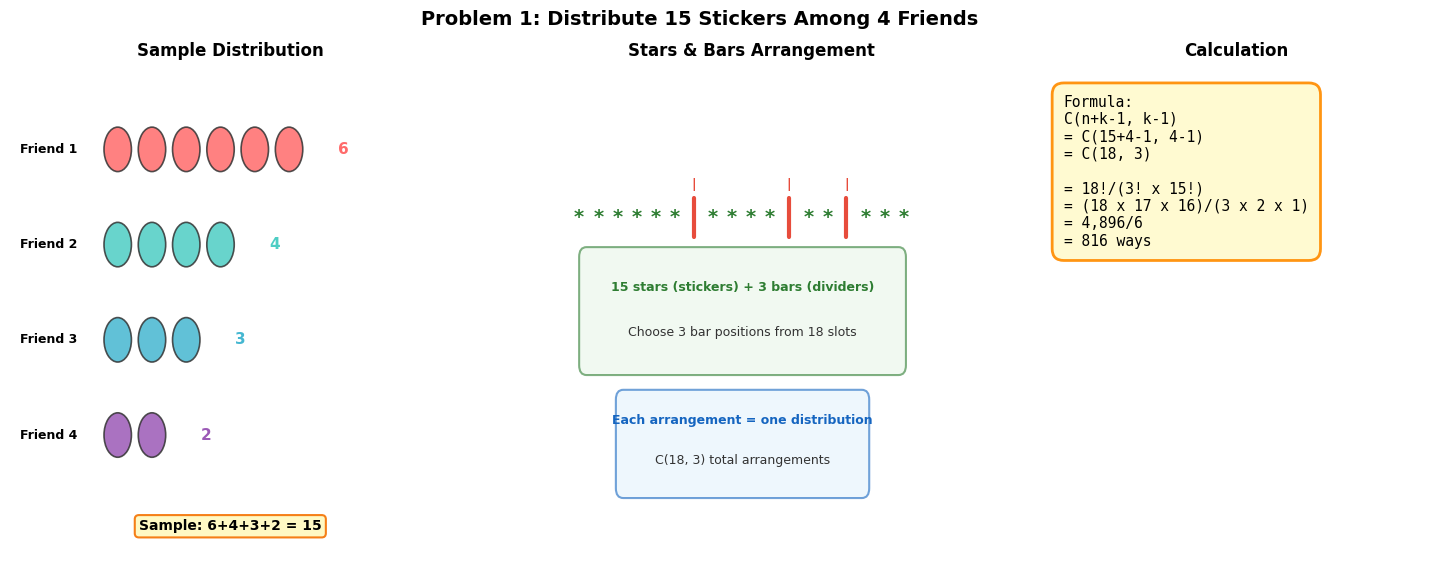

Problem 1 visualization complete


In [54]:
# Visualization: Stickers Problem
fig = plt.figure(figsize=(15, 6))
fig.suptitle('Problem 1: Distribute 15 Stickers Among 4 Friends',
             fontsize=14, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1, 1], wspace=0.3)

# ─── Left: Sample distribution visualization ───
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(-1, 8)
ax1.set_ylim(-1.2, 5)
ax1.axis('off')
ax1.set_title('Sample Distribution', fontsize=12, fontweight='bold', pad=10)

friends = ['Friend 1', 'Friend 2', 'Friend 3', 'Friend 4']
sample_dist = [6, 4, 3, 2]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#9B59B6']

for i, (friend, count, col) in enumerate(zip(friends, sample_dist, colors)):
    y = 4 - i * 1.2
    ax1.text(-0.8, y, friend, fontsize=9, fontweight='bold', ha='left', va='center')
    # Draw stickers as circles in a row for this friend
    for j in range(count):
        circle = patches.Circle((1.2 + j * 0.7, y), 0.28,
                                facecolor=col, edgecolor='#333',
                                linewidth=1.2, alpha=0.85)
        ax1.add_patch(circle)
    ax1.text(1.2 + count * 0.7 + 0.3, y, str(count),
             fontsize=11, fontweight='bold', color=col, va='center')

ax1.text(3.5, -0.8, 'Sample: 6+4+3+2 = 15', ha='center', fontsize=10,
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4',
                   edgecolor='#F57F17', linewidth=1.5))

# ─── Middle: Stars and bars illustration ───
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Stars & Bars Arrangement', fontsize=12, fontweight='bold', pad=10)

# Draw stars and bars with color coding
star_bar_y = 7
sx = 0.3
for k in range(18):
    if k in [6, 11, 14]:  # bar positions (after 6, 10, 13 stars)
        ax2.plot([sx, sx], [star_bar_y - 0.4, star_bar_y + 0.4],
                 color='#E74C3C', linewidth=3, solid_capstyle='round')
        ax2.text(sx, star_bar_y + 0.6, '|', fontsize=9, ha='center',
                 color='#E74C3C', fontweight='bold')
    else:
        ax2.text(sx, star_bar_y, '*', fontsize=14, ha='center',
                 color='#2E7D32', fontweight='bold', va='center')
    sx += 0.52

# Legend
ax2.add_patch(patches.FancyBboxPatch((0.5, 4), 8.5, 2.2,
              boxstyle='round,pad=0.2', facecolor='#E8F5E9',
              edgecolor='#2E7D32', linewidth=1.5, alpha=0.6))
ax2.text(4.75, 5.5, '15 stars (stickers) + 3 bars (dividers)',
         fontsize=9, ha='center', fontweight='bold', color='#2E7D32')
ax2.text(4.75, 4.6, 'Choose 3 bar positions from 18 slots',
         fontsize=9, ha='center', color='#333')

ax2.add_patch(patches.FancyBboxPatch((1.5, 1.5), 6.5, 1.8,
              boxstyle='round,pad=0.2', facecolor='#E3F2FD',
              edgecolor='#1565C0', linewidth=1.5, alpha=0.6))
ax2.text(4.75, 2.8, 'Each arrangement = one distribution',
         fontsize=9, ha='center', fontweight='bold', color='#1565C0')
ax2.text(4.75, 2.0, 'C(18, 3) total arrangements',
         fontsize=9, ha='center', color='#333')

# ─── Right: Formula and calculation ───
ax3 = fig.add_subplot(gs[2])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Calculation', fontsize=12, fontweight='bold', pad=10)

calc_text = ("Formula:\n"
             "C(n+k-1, k-1)\n"
             "= C(15+4-1, 4-1)\n"
             "= C(18, 3)\n\n"
             "= 18!/(3! x 15!)\n"
             "= (18 x 17 x 16)/(3 x 2 x 1)\n"
             "= 4,896/6\n"
             "= 816 ways")

ax3.text(0.3, 9.5, calc_text, fontsize=10.5, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFFACD',
                   edgecolor='#FF8C00', linewidth=2, alpha=0.92))

fig.subplots_adjust(left=0.04, right=0.98, top=0.88, bottom=0.06)
plt.show()

print("Problem 1 visualization complete")


### Problem 2: Non-Negative Solutions

How many non-negative integer solutions does $x_1 + x_2 + x_3 + x_4 + x_5 = 20$ have?

In [55]:
# SOLUTION
n, k = 20, 5
result = C(n + k - 1, k - 1)

print(f"x₁ + x₂ + x₃ + x₄ + x₅ = {n}")
print(f"Non-negative integer solutions: C({n + k - 1}, {k - 1}) = {result:,}")

x₁ + x₂ + x₃ + x₄ + x₅ = 20
Non-negative integer solutions: C(24, 4) = 10,626


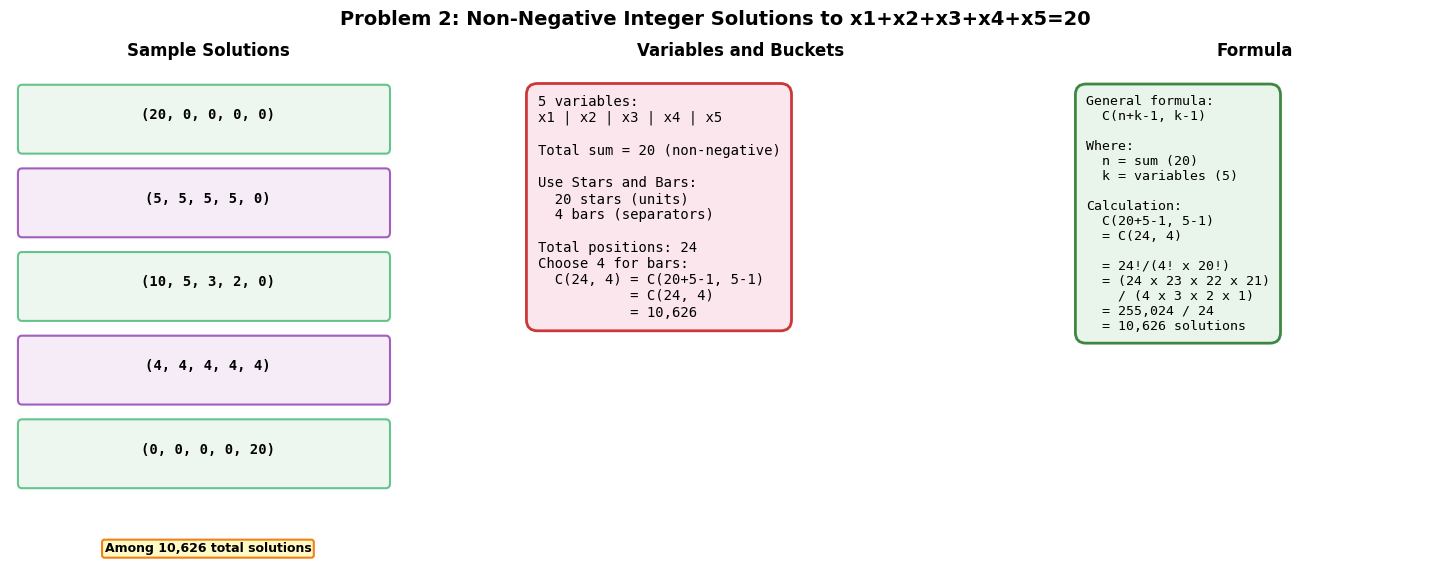

Problem 2 visualization complete


In [56]:
# Visualization: Non-Negative Solutions
fig = plt.figure(figsize=(15, 6))
fig.suptitle('Problem 2: Non-Negative Integer Solutions to x1+x2+x3+x4+x5=20',
             fontsize=14, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.2, 1], wspace=0.3)

# ─── Left: Example solutions ───
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Sample Solutions', fontsize=12, fontweight='bold', pad=10)

examples = [
    (20, 0, 0, 0, 0),
    (5, 5, 5, 5, 0),
    (10, 5, 3, 2, 0),
    (4, 4, 4, 4, 4),
    (0, 0, 0, 0, 20),
]
box_colors = ['#E8F5E9', '#F3E5F5', '#E8F5E9', '#F3E5F5', '#E8F5E9']
edge_colors = ['#27ae60', '#7B1FA2', '#27ae60', '#7B1FA2', '#27ae60']

for i, (sol_tuple, fc, ec) in enumerate(zip(examples, box_colors, edge_colors)):
    y = 8.8 - i * 1.7
    sol_str = '(' + ', '.join(str(v) for v in sol_tuple) + ')'
    rect = patches.FancyBboxPatch((0.3, y - 0.4), 9.2, 1.2,
                                   boxstyle='round,pad=0.1',
                                   facecolor=fc, edgecolor=ec,
                                   linewidth=1.5, alpha=0.7)
    ax1.add_patch(rect)
    ax1.text(5, y + 0.2, sol_str, ha='center', fontsize=10,
             family='monospace', fontweight='bold')

ax1.text(5, 0.2, 'Among 10,626 total solutions', ha='center', fontsize=9,
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFF9C4',
                   edgecolor='#F57F17', linewidth=1.5))

# ─── Middle: Stars and Bars explanation ───
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Variables and Buckets', fontsize=12, fontweight='bold', pad=10)

var_text = ("5 variables:\n"
            "x1 | x2 | x3 | x4 | x5\n\n"
            "Total sum = 20 (non-negative)\n\n"
            "Use Stars and Bars:\n"
            "  20 stars (units)\n"
            "  4 bars (separators)\n\n"
            "Total positions: 24\n"
            "Choose 4 for bars:\n"
            "  C(24, 4) = C(20+5-1, 5-1)\n"
            "           = C(24, 4)\n"
            "           = 10,626")

ax2.text(0.3, 9.5, var_text, fontsize=10, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#FCE4EC',
                   edgecolor='#C62828', linewidth=2, alpha=0.92))

# ─── Right: Calculation ───
ax3 = fig.add_subplot(gs[2])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Formula', fontsize=12, fontweight='bold', pad=10)

formula_text = ("General formula:\n"
                "  C(n+k-1, k-1)\n\n"
                "Where:\n"
                "  n = sum (20)\n"
                "  k = variables (5)\n\n"
                "Calculation:\n"
                "  C(20+5-1, 5-1)\n"
                "  = C(24, 4)\n\n"
                "  = 24!/(4! x 20!)\n"
                "  = (24 x 23 x 22 x 21)\n"
                "    / (4 x 3 x 2 x 1)\n"
                "  = 255,024 / 24\n"
                "  = 10,626 solutions")

ax3.text(0.3, 9.5, formula_text, fontsize=9.5, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#E8F5E9',
                   edgecolor='#2E7D32', linewidth=2, alpha=0.92))

fig.subplots_adjust(left=0.03, right=0.98, top=0.88, bottom=0.06)
plt.show()

print("Problem 2 visualization complete")


### Problem 3: Positive Solutions

How many **positive** integer solutions does $x_1 + x_2 + x_3 + x_4 = 18$ have?

(Each $x_i \geq 1$.)

In [57]:
# SOLUTION
n, k = 18, 4
result = C(n - 1, k - 1)

print(f"x₁ + x₂ + x₃ + x₄ = {n}, each xᵢ ≥ 1")
print(f"C({n - 1}, {k - 1}) = {result}")

x₁ + x₂ + x₃ + x₄ = 18, each xᵢ ≥ 1
C(17, 3) = 680


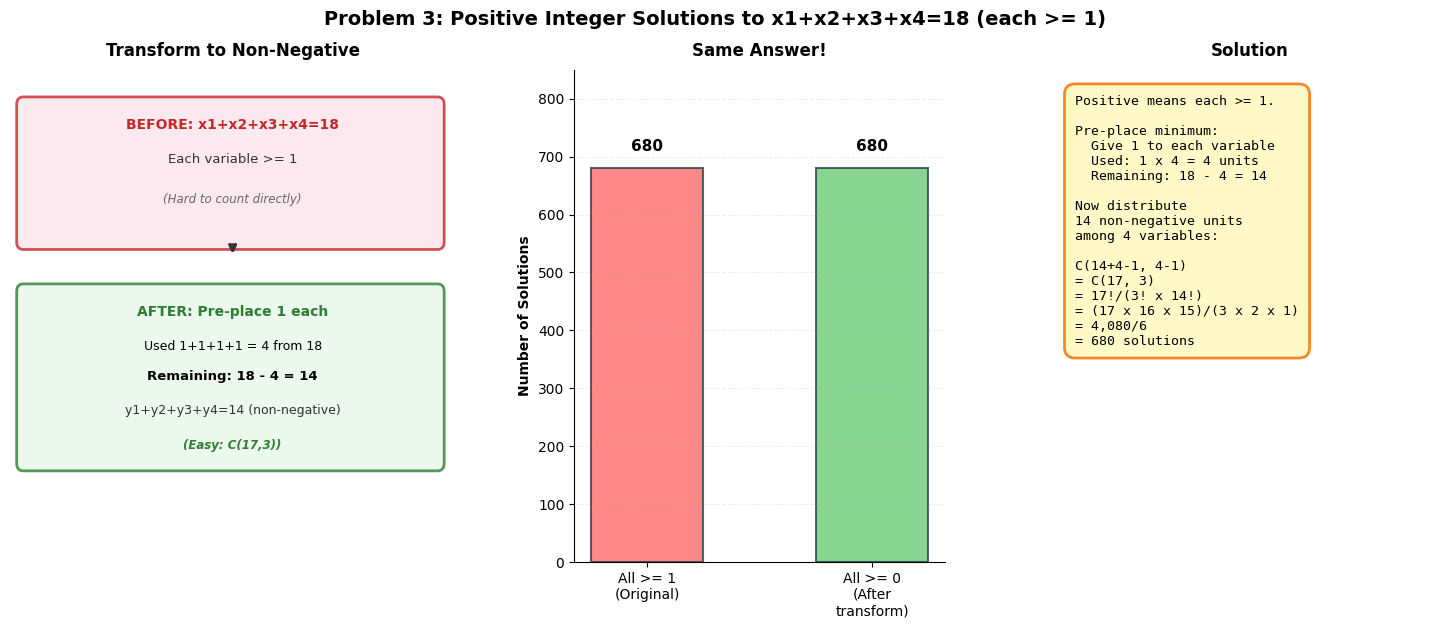

Problem 3 visualization complete


In [58]:
# Visualization: Positive Solutions (each xi >= 1)
fig = plt.figure(figsize=(15, 6))
fig.suptitle('Problem 3: Positive Integer Solutions to x1+x2+x3+x4=18 (each >= 1)',
             fontsize=14, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1, 1], wspace=0.3)

# ─── Left: Before and after pre-placement ───
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Transform to Non-Negative', fontsize=12, fontweight='bold', pad=10)

# Before box
rect = patches.FancyBboxPatch((0.3, 6.5), 9.3, 2.8,
                               boxstyle='round,pad=0.15',
                               facecolor='#FCE4EC', edgecolor='#C62828',
                               linewidth=2, alpha=0.8)
ax1.add_patch(rect)
ax1.text(5, 8.8, 'BEFORE: x1+x2+x3+x4=18',
         fontsize=10, ha='center', fontweight='bold', color='#C62828')
ax1.text(5, 8.1, 'Each variable >= 1', fontsize=9.5, ha='center', color='#333')
ax1.text(5, 7.3, '(Hard to count directly)',
         fontsize=8.5, ha='center', style='italic', color='#666')

# Arrow
ax1.annotate('', xy=(5, 6.2), xytext=(5, 6.5),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))

# After box
rect = patches.FancyBboxPatch((0.3, 2), 9.3, 3.5,
                               boxstyle='round,pad=0.15',
                               facecolor='#E8F5E9', edgecolor='#2E7D32',
                               linewidth=2, alpha=0.8)
ax1.add_patch(rect)
ax1.text(5, 5, 'AFTER: Pre-place 1 each',
         fontsize=10, ha='center', fontweight='bold', color='#2E7D32')
ax1.text(5, 4.3, 'Used 1+1+1+1 = 4 from 18', fontsize=9, ha='center')
ax1.text(5, 3.7, 'Remaining: 18 - 4 = 14',
         fontsize=9.5, ha='center', fontweight='bold')
ax1.text(5, 3, 'y1+y2+y3+y4=14 (non-negative)', fontsize=9, ha='center', color='#333')
ax1.text(5, 2.3, '(Easy: C(17,3))',
         fontsize=8.5, ha='center', style='italic', color='#2E7D32',
         fontweight='bold')

# ─── Middle: Comparison bar chart ───
ax2 = fig.add_subplot(gs[1])
labels = ['All >= 1\n(Original)', 'All >= 0\n(After\ntransform)']
values_pos = [C(18-1, 4-1), C(14+4-1, 4-1)]
colors_bar = ['#FF6B6B', '#6BCB77']

bars = ax2.bar(labels, values_pos, color=colors_bar, edgecolor='#2C3E50',
               linewidth=1.5, width=0.5, alpha=0.8)
for bar, val in zip(bars, values_pos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')

ax2.set_ylabel('Number of Solutions', fontsize=10, fontweight='bold')
ax2.set_title('Same Answer!', fontsize=12, fontweight='bold', pad=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylim(0, max(values_pos) * 1.25)
ax2.grid(axis='y', alpha=0.2, linestyle='--')

# ─── Right: Formula ───
ax3 = fig.add_subplot(gs[2])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Solution', fontsize=12, fontweight='bold', pad=10)

sol_text = ("Positive means each >= 1.\n\n"
            "Pre-place minimum:\n"
            "  Give 1 to each variable\n"
            "  Used: 1 x 4 = 4 units\n"
            "  Remaining: 18 - 4 = 14\n\n"
            "Now distribute\n"
            "14 non-negative units\n"
            "among 4 variables:\n\n"
            "C(14+4-1, 4-1)\n"
            "= C(17, 3)\n"
            "= 17!/(3! x 14!)\n"
            "= (17 x 16 x 15)/(3 x 2 x 1)\n"
            "= 4,080/6\n"
            "= 680 solutions")

ax3.text(0.3, 9.5, sol_text, fontsize=9.5, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9C4',
                   edgecolor='#F57F17', linewidth=2, alpha=0.92))

fig.subplots_adjust(left=0.03, right=0.98, top=0.88, bottom=0.06)
plt.show()

print("Problem 3 visualization complete")


### Problem 4: Buying Bagels

A bagel shop sells **5 types** of bagels. You buy a dozen (**12 bagels**).

**Part A**: How many selections if no restriction?

**Part B**: How many if you must buy **at least 1** of each type?

In [59]:
# SOLUTION
n_types = 5
total = 12

# Part A: No restriction — distribute 12 among 5 types (≥0)
part_a = C(total + n_types - 1, n_types - 1)
print(f"Part A: C({total + n_types - 1}, {n_types - 1}) = {part_a}")

# Part B: At least 1 of each — pre-place 1 per type, then distribute 7 freely
remaining = total - n_types
part_b = C(remaining + n_types - 1, n_types - 1)
print(f"Part B: Pre-place 1 each → {remaining} left")
print(f"        C({remaining + n_types - 1}, {n_types - 1}) = {part_b}")

Part A: C(16, 4) = 1820
Part B: Pre-place 1 each → 7 left
        C(11, 4) = 330


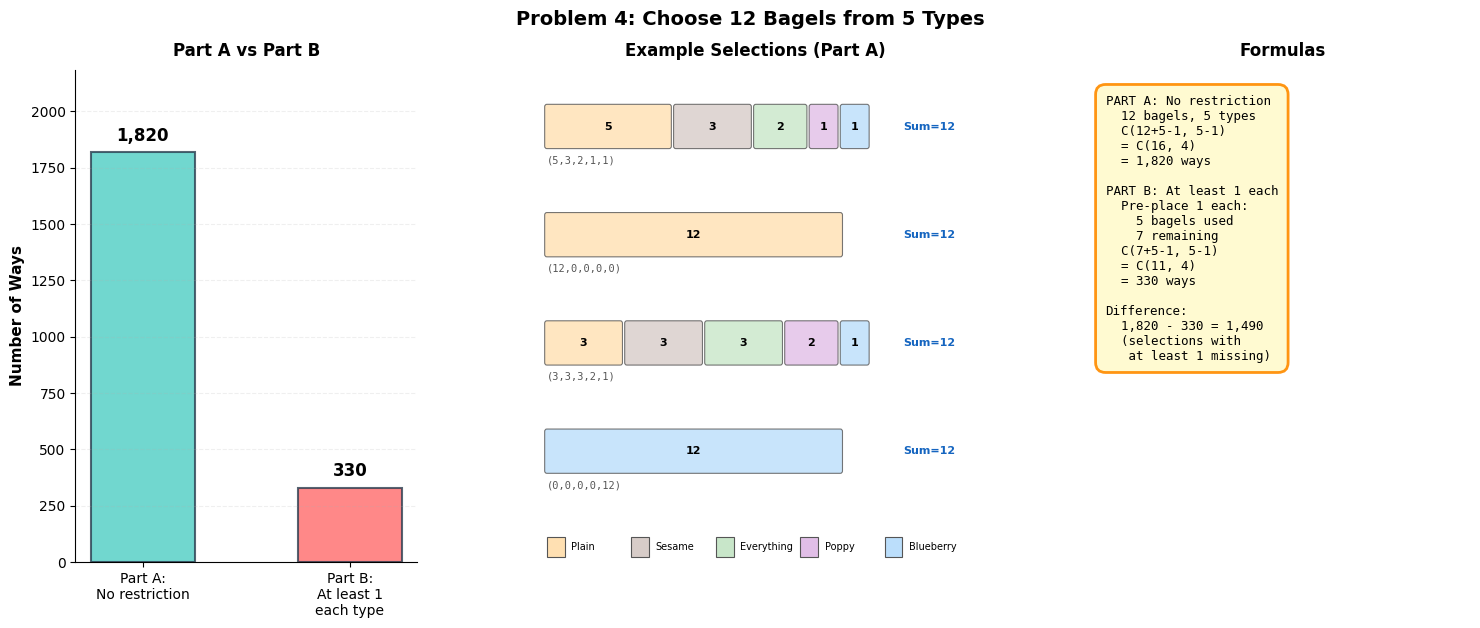

Problem 4 visualization complete


In [60]:
# Visualization: Bagels Problem
fig = plt.figure(figsize=(15, 6))
fig.suptitle('Problem 4: Choose 12 Bagels from 5 Types',
             fontsize=14, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.3, 1.1], wspace=0.3)

# ─── Left: Part A vs Part B comparison ───
ax1 = fig.add_subplot(gs[0])
part_a = C(12 + 5 - 1, 5 - 1)
part_b = C(12 - 5 + 5 - 1, 5 - 1)

categories = ['Part A:\nNo restriction', 'Part B:\nAt least 1\neach type']
values = [part_a, part_b]
colors_bar = ['#4ECDC4', '#FF6B6B']

bars = ax1.bar(categories, values, color=colors_bar, edgecolor='#2C3E50',
               linewidth=1.5, width=0.5, alpha=0.8)

for bar, val in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 50,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')

ax1.set_ylabel('Number of Ways', fontsize=11, fontweight='bold')
ax1.set_title('Part A vs Part B', fontsize=12, fontweight='bold', pad=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, max(values) * 1.2)
ax1.grid(axis='y', alpha=0.2, linestyle='--')

# ─── Middle: Bagel type examples ───
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Example Selections (Part A)', fontsize=12, fontweight='bold', pad=10)

bagel_types = ['Plain', 'Sesame', 'Everything', 'Poppy', 'Blueberry']
type_colors = ['#FFE0B2', '#D7CCC8', '#C8E6C9', '#E1BEE7', '#BBDEFB']
examples_a = [
    [5, 3, 2, 1, 1],
    [12, 0, 0, 0, 0],
    [3, 3, 3, 2, 1],
    [0, 0, 0, 0, 12],
]

for i, dist in enumerate(examples_a):
    y = 8.8 - i * 2.2
    # Colored boxes per type
    x_start = 0.3
    for j, (cnt, tc) in enumerate(zip(dist, type_colors)):
        width = max(cnt * 0.55, 0.4) if cnt > 0 else 0
        if cnt > 0:
            rect = patches.FancyBboxPatch((x_start, y - 0.35), width, 0.8,
                                           boxstyle='round,pad=0.05',
                                           facecolor=tc, edgecolor='#555',
                                           linewidth=0.8, alpha=0.8)
            ax2.add_patch(rect)
            ax2.text(x_start + width/2, y + 0.05, str(cnt), ha='center',
                     fontsize=8, fontweight='bold', va='center')
            x_start += width + 0.15

    dist_str = '(' + ','.join(str(d) for d in dist) + ')'
    ax2.text(9.5, y + 0.05, f'Sum=12', fontsize=8, ha='right',
             fontweight='bold', va='center', color='#1565C0')
    ax2.text(0.3, y - 0.7, dist_str, fontsize=7.5, family='monospace',
             color='#555')

# Type legend at bottom
for j, (name, tc) in enumerate(zip(bagel_types, type_colors)):
    x_leg = 0.3 + j * 1.9
    rect = patches.Rectangle((x_leg, 0.1), 0.4, 0.4,
                               facecolor=tc, edgecolor='#555', linewidth=0.8)
    ax2.add_patch(rect)
    ax2.text(x_leg + 0.55, 0.3, name, fontsize=7, va='center')

# ─── Right: Formulas ───
ax3 = fig.add_subplot(gs[2])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Formulas', fontsize=12, fontweight='bold', pad=10)

formula_text = ("PART A: No restriction\n"
                "  12 bagels, 5 types\n"
                "  C(12+5-1, 5-1)\n"
                "  = C(16, 4)\n"
                "  = 1,820 ways\n\n"
                "PART B: At least 1 each\n"
                "  Pre-place 1 each:\n"
                "    5 bagels used\n"
                "    7 remaining\n"
                "  C(7+5-1, 5-1)\n"
                "  = C(11, 4)\n"
                "  = 330 ways\n\n"
                "Difference:\n"
                "  1,820 - 330 = 1,490\n"
                "  (selections with\n"
                "   at least 1 missing)")

ax3.text(0.3, 9.5, formula_text, fontsize=9, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFFACD',
                   edgecolor='#FF8C00', linewidth=2, alpha=0.92))

fig.subplots_adjust(left=0.05, right=0.98, top=0.88, bottom=0.06)
plt.show()

print("Problem 4 visualization complete")


### Problem 5: Upper Bound

Distribute **9 identical balls** into **3 boxes**, each box holding **at most 5** balls.

Hint: Use inclusion-exclusion.

In [61]:
# SOLUTION
n = 9
k = 3
M = 5
excess = M + 1

# Total without upper bound
total = C(n + k - 1, k - 1)

# At least 1 box > 5: pre-place 6 in one box
r1 = n - excess
one_over = C(k, 1) * C(r1 + k - 1, k - 1)

# At least 2 boxes > 5: pre-place 12 total
r2 = n - 2 * excess
if r2 >= 0:
    two_over = C(k, 2) * C(r2 + k - 1, k - 1)
else:
    two_over = 0

result = total - one_over + two_over

print(f"Distribute {n} balls into {k} boxes, each ≤ {M}")
print(f"Total (no cap):          {total}")
print(f"≥1 box exceeds {M}:       {one_over}")
print(f"≥2 boxes exceed {M}:      {two_over} (impossible)")
print(f"Result: {total} - {one_over} + {two_over} = {result}")
print()

# Brute force check
count = 0
for b1 in range(M + 1):
    for b2 in range(M + 1):
        b3 = n - b1 - b2
        if 0 <= b3 <= M:
            count += 1

print(f"Brute force: {count}")
print(f"Match: {'✓' if count == result else '✗'}")

Distribute 9 balls into 3 boxes, each ≤ 5
Total (no cap):          55
≥1 box exceeds 5:       30
≥2 boxes exceed 5:      0 (impossible)
Result: 55 - 30 + 0 = 25

Brute force: 25
Match: ✓


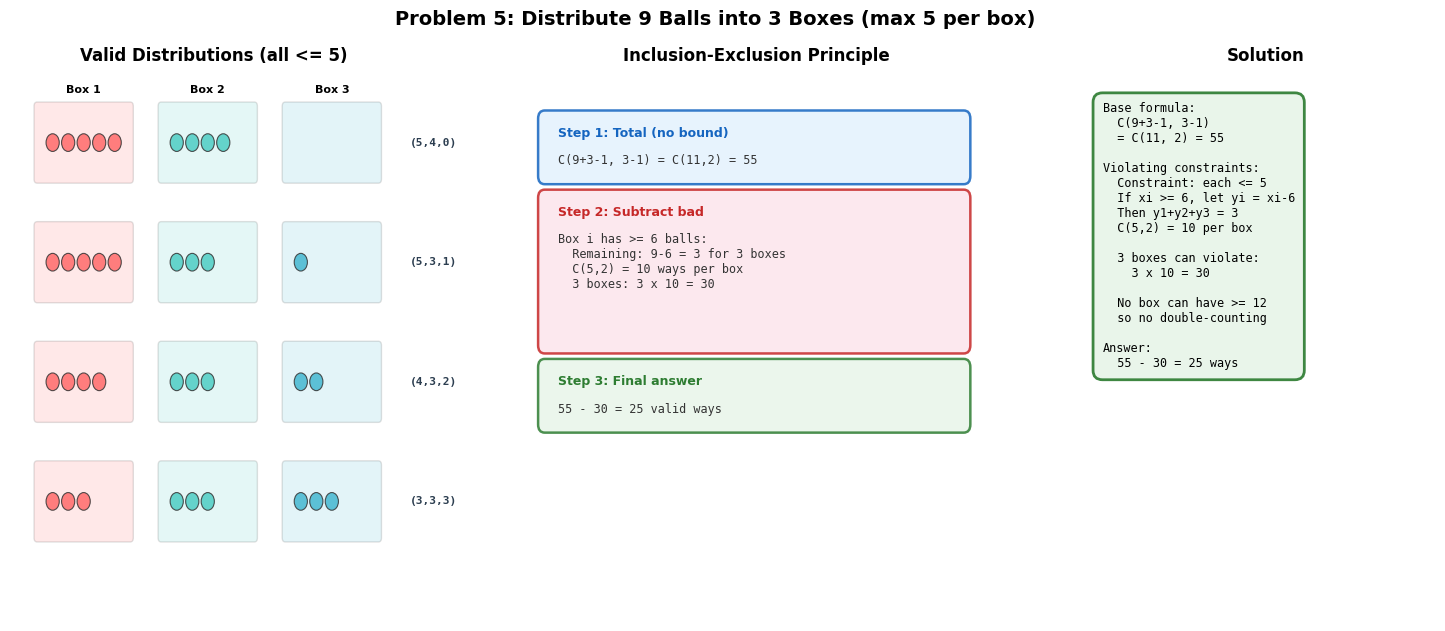

Problem 5 visualization complete


In [62]:
# Visualization: Upper Bound (Inclusion-Exclusion)
fig = plt.figure(figsize=(15, 6.5))
fig.suptitle('Problem 5: Distribute 9 Balls into 3 Boxes (max 5 per box)',
             fontsize=14, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.3, 1], wspace=0.3)

# ─── Left: Valid distribution examples with colored boxes ───
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(-0.5, 10)
ax1.set_ylim(-0.5, 10)
ax1.axis('off')
ax1.set_title('Valid Distributions (all <= 5)', fontsize=12, fontweight='bold', pad=10)

distributions = [(5, 4, 0), (5, 3, 1), (4, 3, 2), (3, 3, 3)]
box_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, dist in enumerate(distributions):
    y_base = 8.5 - idx * 2.3

    for box_idx, ball_count in enumerate(dist):
        x_start = 0.2 + box_idx * 3.2

        # Box background
        rect = patches.FancyBboxPatch((x_start, y_base - 0.5), 2.4, 1.4,
                                       boxstyle='round,pad=0.08',
                                       facecolor=box_colors[box_idx],
                                       edgecolor='#333', linewidth=1,
                                       alpha=0.15)
        ax1.add_patch(rect)

        # Draw balls inside box
        for b in range(ball_count):
            bx = x_start + 0.4 + b * 0.4
            circle = patches.Circle((bx, y_base + 0.2), 0.17,
                                    facecolor=box_colors[box_idx],
                                    edgecolor='#333', linewidth=0.8,
                                    alpha=0.85)
            ax1.add_patch(circle)

        # Box label (only for first row)
        if idx == 0:
            ax1.text(x_start + 1.2, y_base + 1.15, f'Box {box_idx+1}',
                     fontsize=8, ha='center', fontweight='bold')

    # Distribution tuple
    ax1.text(9.8, y_base + 0.2, f'({dist[0]},{dist[1]},{dist[2]})',
             fontsize=8, fontweight='bold', color='#2C3E50',
             family='monospace', va='center')

# ─── Middle: Inclusion-Exclusion principle ───
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Inclusion-Exclusion Principle', fontsize=12, fontweight='bold', pad=10)

# Step boxes
steps = [
    ('Step 1: Total (no bound)', '#E3F2FD', '#1565C0',
     'C(9+3-1, 3-1) = C(11,2) = 55'),
    ('Step 2: Subtract bad', '#FCE4EC', '#C62828',
     'Box i has >= 6 balls:\n'
     '  Remaining: 9-6 = 3 for 3 boxes\n'
     '  C(5,2) = 10 ways per box\n'
     '  3 boxes: 3 x 10 = 30'),
    ('Step 3: Final answer', '#E8F5E9', '#2E7D32',
     '55 - 30 = 25 valid ways'),
]

y_pos = 9.2
for title, fc, ec, content in steps:
    lines = content.count('\n') + 1
    box_h = 0.5 + lines * 0.55
    rect = patches.FancyBboxPatch((0.2, y_pos - box_h), 9.5, box_h,
                                   boxstyle='round,pad=0.15',
                                   facecolor=fc, edgecolor=ec,
                                   linewidth=1.8, alpha=0.85)
    ax2.add_patch(rect)
    ax2.text(0.5, y_pos - 0.15, title, fontsize=9,
             fontweight='bold', color=ec, va='top')
    ax2.text(0.5, y_pos - 0.65, content, fontsize=8.5,
             family='monospace', va='top', color='#333')
    y_pos -= box_h + 0.4

# ─── Right: Calculation ───
ax3 = fig.add_subplot(gs[2])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Solution', fontsize=12, fontweight='bold', pad=10)

calc_text = ("Base formula:\n"
             "  C(9+3-1, 3-1)\n"
             "  = C(11, 2) = 55\n\n"
             "Violating constraints:\n"
             "  Constraint: each <= 5\n"
             "  If xi >= 6, let yi = xi-6\n"
             "  Then y1+y2+y3 = 3\n"
             "  C(5,2) = 10 per box\n\n"
             "  3 boxes can violate:\n"
             "    3 x 10 = 30\n\n"
             "  No box can have >= 12\n"
             "  so no double-counting\n\n"
             "Answer:\n"
             "  55 - 30 = 25 ways")

ax3.text(0.2, 9.5, calc_text, fontsize=8.5, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#E8F5E9',
                   edgecolor='#2E7D32', linewidth=2, alpha=0.92))

fig.subplots_adjust(left=0.03, right=0.98, top=0.88, bottom=0.04)
plt.show()

print("Problem 5 visualization complete")


### Problem 6: Mixed Constraints

How many ways to distribute **20 identical coins** among **3 people** such that:
- Person A gets **at least 3**
- Person B gets **at least 5**
- Person C gets **at least 0**

Hint: Pre-place the minimums, then distribute the rest freely.

In [63]:
# SOLUTION
total_coins = 20
min_a, min_b, min_c = 3, 5, 0
k = 3

# Pre-place minimums
used = min_a + min_b + min_c
remaining = total_coins - used

result = C(remaining + k - 1, k - 1)

print(f"Coins: {total_coins}")
print(f"Minimums: A ≥ {min_a}, B ≥ {min_b}, C ≥ {min_c}")
print(f"Pre-place: {min_a} + {min_b} + {min_c} = {used}")
print(f"Remaining: {remaining}")
print(f"C({remaining + k - 1}, {k - 1}) = {result}")

Coins: 20
Minimums: A ≥ 3, B ≥ 5, C ≥ 0
Pre-place: 3 + 5 + 0 = 8
Remaining: 12
C(14, 2) = 91


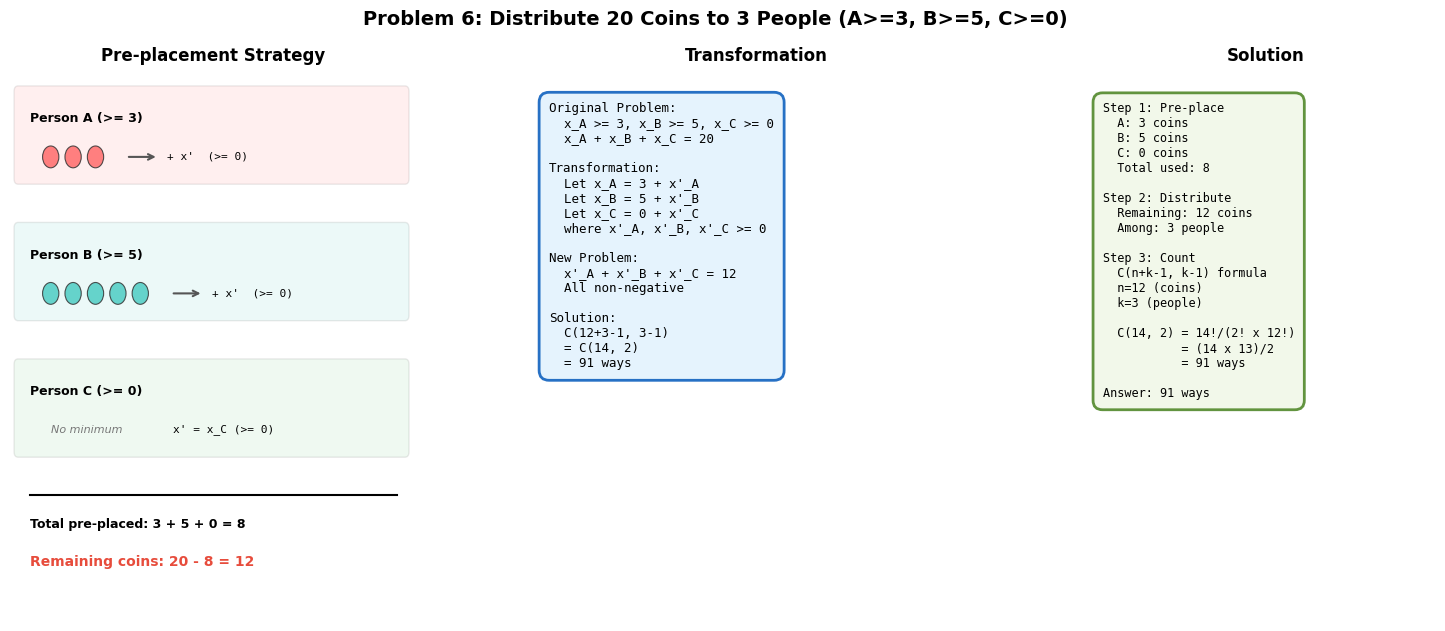

Problem 6 visualization complete


In [64]:
# Visualization: Mixed Constraints (Minimum Requirements)
fig = plt.figure(figsize=(15, 6.5))
fig.suptitle('Problem 6: Distribute 20 Coins to 3 People (A>=3, B>=5, C>=0)',
             fontsize=14, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.3, 1], wspace=0.3)

# ─── Left: Constraint visualization ───
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Pre-placement Strategy', fontsize=12, fontweight='bold', pad=10)

people_data = [
    ('Person A (>= 3)', 3, '#FF6B6B'),
    ('Person B (>= 5)', 5, '#4ECDC4'),
    ('Person C (>= 0)', 0, '#6BCB77'),
]

for idx, (person, coins, color) in enumerate(people_data):
    y_pos = 8.5 - idx * 2.5

    # Person label box
    rect = patches.FancyBboxPatch((0.2, y_pos - 0.4), 9.5, 1.6,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, edgecolor='#333',
                                   linewidth=1, alpha=0.1)
    ax1.add_patch(rect)

    ax1.text(0.5, y_pos + 0.7, person, fontsize=9, fontweight='bold', va='center')

    # Pre-placed coins (larger circles)
    for coin_id in range(coins):
        circle = patches.Circle((1.0 + coin_id * 0.55, y_pos), 0.2,
                                facecolor=color, edgecolor='#333',
                                linewidth=0.8, alpha=0.85)
        ax1.add_patch(circle)

    # Arrow and remaining variable
    if coins > 0:
        arrow_x = 1.0 + coins * 0.55 + 0.2
        ax1.annotate('', xy=(arrow_x + 0.8, y_pos),
                     xytext=(arrow_x, y_pos),
                     arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))
        ax1.text(arrow_x + 1, y_pos, f"+ x'  (>= 0)",
                 fontsize=8, va='center', family='monospace')
    else:
        ax1.text(1.0, y_pos, 'No minimum', fontsize=8, va='center',
                 style='italic', color='#777')
        ax1.text(4.0, y_pos, f"x' = x_C (>= 0)",
                 fontsize=8, va='center', family='monospace')

# Summary line
ax1.plot([0.5, 9.5], [2.3, 2.3], 'k-', linewidth=1.5)
ax1.text(0.5, 1.7, 'Total pre-placed: 3 + 5 + 0 = 8',
         fontsize=9, fontweight='bold')
ax1.text(0.5, 1.0, 'Remaining coins: 20 - 8 = 12',
         fontsize=10, fontweight='bold', color='#E74C3C')

# ─── Middle: Distribution transformation ───
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Transformation', fontsize=12, fontweight='bold', pad=10)

transform_text = ("Original Problem:\n"
                  "  x_A >= 3, x_B >= 5, x_C >= 0\n"
                  "  x_A + x_B + x_C = 20\n\n"
                  "Transformation:\n"
                  "  Let x_A = 3 + x'_A\n"
                  "  Let x_B = 5 + x'_B\n"
                  "  Let x_C = 0 + x'_C\n"
                  "  where x'_A, x'_B, x'_C >= 0\n\n"
                  "New Problem:\n"
                  "  x'_A + x'_B + x'_C = 12\n"
                  "  All non-negative\n\n"
                  "Solution:\n"
                  "  C(12+3-1, 3-1)\n"
                  "  = C(14, 2)\n"
                  "  = 91 ways")

ax2.text(0.3, 9.5, transform_text, fontsize=9, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#E3F2FD',
                   edgecolor='#1565C0', linewidth=2, alpha=0.92))

# ─── Right: Final calculation ───
ax3 = fig.add_subplot(gs[2])
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Solution', fontsize=12, fontweight='bold', pad=10)

calc_text = ("Step 1: Pre-place\n"
             "  A: 3 coins\n"
             "  B: 5 coins\n"
             "  C: 0 coins\n"
             "  Total used: 8\n\n"
             "Step 2: Distribute\n"
             "  Remaining: 12 coins\n"
             "  Among: 3 people\n\n"
             "Step 3: Count\n"
             "  C(n+k-1, k-1) formula\n"
             "  n=12 (coins)\n"
             "  k=3 (people)\n\n"
             "  C(14, 2) = 14!/(2! x 12!)\n"
             "           = (14 x 13)/2\n"
             "           = 91 ways\n\n"
             "Answer: 91 ways")

ax3.text(0.2, 9.5, calc_text, fontsize=8.5, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#F1F8E9',
                   edgecolor='#558B2F', linewidth=2, alpha=0.92))

fig.subplots_adjust(left=0.03, right=0.98, top=0.88, bottom=0.04)
plt.show()

print("Problem 6 visualization complete")


---
## 9. What's Next?

With stars and bars we complete the core counting toolkit:

| Notebook | Topic |
|----------|-------|
| 001 | Counting — product rule, sum rule |
| 002 | Permutations — ordered arrangements |
| 003 | Combinations — unordered selections |
| **004** | **Stars and bars — distributions and multisets** |

Next directions:
- **Probability** — using these counting tools to compute probabilities
- **Binomial theorem** — connecting $C(n, r)$ to algebra
- **Inclusion-exclusion** — systematic overcounting correction